## Importing Dataset

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [172]:
df = pd.read_csv('netflix_titles.csv', encoding='latin-1')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


## Dataset Summary

In [173]:
print('Basic Info :', df.info())

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB
Basic Info : None


In [174]:
print('Shape : ', df.shape)

Shape :  (8807, 12)


In [175]:
print('Size : ', df.size)

Size :  105684


In [176]:
print('Sample')
df.head(5)

Sample


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [177]:
print('Missing Values : ', df.isnull().sum())

Missing Values :  show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [178]:
print('Unique Values : ', df.nunique())

Unique Values :  show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64


In [179]:
print('Duplicated Rows : ', df.duplicated().sum())

Duplicated Rows :  0


## Handle missing values

In [180]:
# Fill missing values
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")

# Drop remaining missing rows (rating, duration, date_added)
df = df.dropna()

print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nNew shape:", df.shape)

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

New shape: (8790, 12)


## Queries

In [181]:
# Q1: How many Movies vs TV Shows?
print(df['type'].value_counts())

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


In [182]:
# Q2: Which are the top 10 countries producing content?
print(df['country'].value_counts().head(10))

country
United States     2809
India              972
Unknown            829
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


In [183]:
# Q3: What's the most common rating?
print(df['rating'].value_counts())

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


In [184]:
# Q4: Which year had the most content added to Netflix?
df['year_added'] = df['date_added'].str.strip().str[-4:]
print(df['year_added'].value_counts().sort_index())

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


In [185]:
# Q5 What are the most common durations?
print("Most common durations:")
print(df['duration'].value_counts().head(10))

Most common durations:
duration
1 Season     1791
2 Seasons     421
3 Seasons     198
90 min        152
94 min        146
97 min        146
93 min        146
91 min        144
95 min        137
96 min        130
Name: count, dtype: int64


In [186]:
# Q6 What years does the data cover?
print("Release year range:", df['release_year'].min(), "to", df['release_year'].max())

Release year range: 1925 to 2021


In [187]:
# Q7 What are the unique ratings?
print("Ratings:", df['rating'].unique())

Ratings: <StringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',       'NR',
 'TV-Y7-FV',       'UR']
Length: 14, dtype: str


## EDA Visualizations

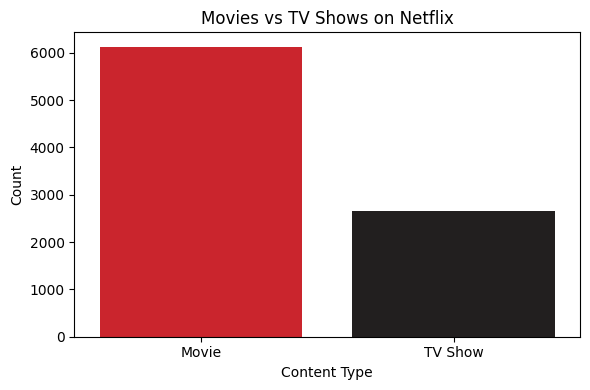

In [188]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type', hue='type', palette=['#E50914', '#221F1F'], legend=False)
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

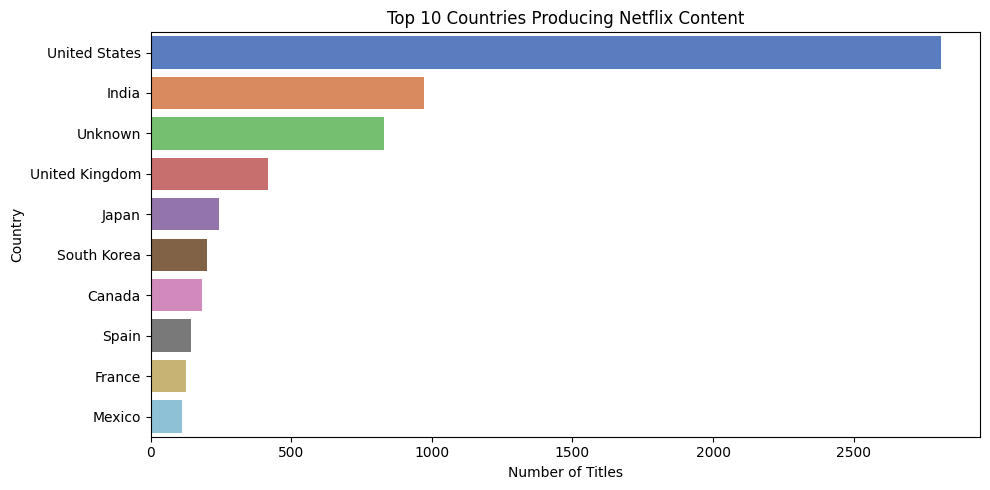

In [189]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='muted', legend=False)
plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

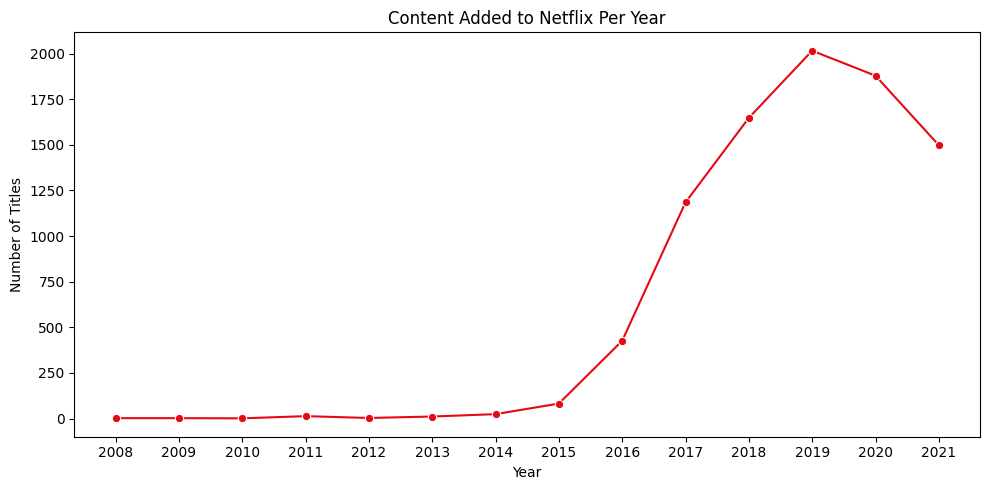

In [190]:
year_counts = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='#E50914')
plt.title('Content Added to Netflix Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

## EDA Summary

In [191]:
print("--| EDA Summary |--")
print(f"Total Titles: {len(df)}")
print(f"Movies: {df[df['type']=='Movie'].shape[0]}")
print(f"TV Shows: {df[df['type']=='TV Show'].shape[0]}")
print(f"Countries Represented: {df['country'].nunique()}")
print(f"Year Range: {df['release_year'].min()} - {df['release_year'].max()}")
print(f"Most Common Rating: {df['rating'].value_counts().index[0]}")
print(f"Peak Year Added: {df['year_added'].value_counts().index[0]}")

--| EDA Summary |--
Total Titles: 8790
Movies: 6126
TV Shows: 2664
Countries Represented: 749
Year Range: 1925 - 2021
Most Common Rating: TV-MA
Peak Year Added: 2019


In [192]:
# EDA Conclusions:
# 1. Netflix library is dominated by Movies (70%) over TV Shows (30%)
# 2. USA and India are the top content producing countries
# 3. Netflix primarily targets adult audiences (TV-MA most common rating)
# 4. Content addition peaked in 2019 then declined due to market competition
# 5. Netflix has a truly global library spanning 749 countries and content from 1925